# Klasifikacija šahovskih završnica koristeći duboko učenje

**Autor**: Mina Radenković SV76/2022  
**Predmet**: Osnove računarske inteligencije  
**Fakultet**: FTN, Univerzitet u Novom Sadu

---

## 📋 Pregled projekta

Ovaj projekat implementira sistem za klasifikaciju šahovskih završnica koristeći duboko učenje. Sistem može da:
- **Klasifikuje tip završnice** (npr. "Kralj+Pešak protiv Kralja", "Top protiv Pešaka")
- **Predviđa ishod partije** (Pobeda/Remi/Poraz) sa verovatnoćama
- **Pruža edukativni interfejs** za šahiste i trenere


## 🎯 Problem i motivacija

### Problem
Završnice su jedan od najtežih segmenata šaha za učenje. Iako postoje teoretske baze podataka (tablebase) sa potpuno tačnim rešenjima, one nisu user-friendly za igrače koji žele objašnjenja i trening.

### Rešenje
Kreiranje inteligentnog sistema koji automatski prepoznaje tip završnice i predviđa ishod na osnovu FEN notacije pozicije.


## 📊 Dataset i podaci

Koristimo **Syzygy tablebase** podatke za 3-4-5 figura završnice:


Ukupno pozicija: 250,000
Broj tipova završnica: 196
Broj figura: 2-6


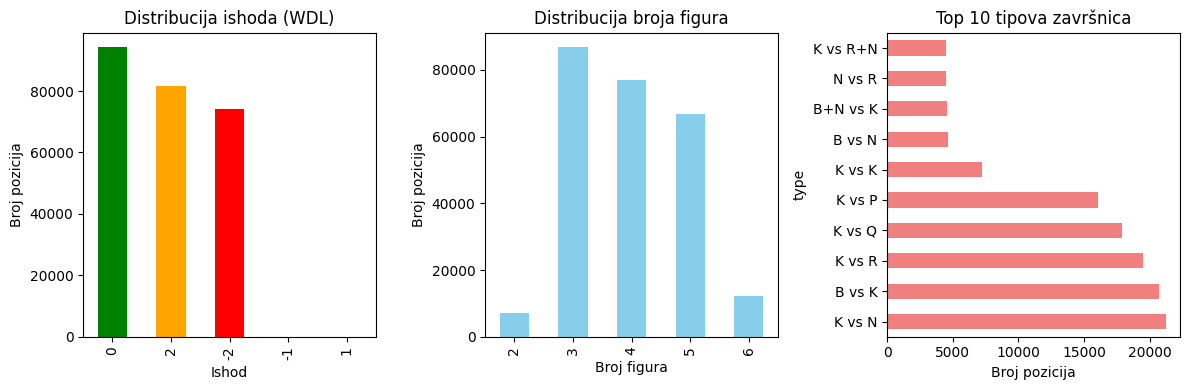

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Učitavanje dataset-a
df = pd.read_csv('data/generated_data.csv')

print(f"Ukupno pozicija: {len(df):,}")
print(f"Broj tipova završnica: {df['type'].nunique()}")
print(f"Broj figura: {df['num_pieces'].min()}-{df['num_pieces'].max()}")

# Prikaz distribucije ishoda
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['wdl'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribucija ishoda (WDL)')
plt.xlabel('Ishod')
plt.ylabel('Broj pozicija')

plt.subplot(1, 3, 2)
df['num_pieces'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribucija broja figura')
plt.xlabel('Broj figura')
plt.ylabel('Broj pozicija')

plt.subplot(1, 3, 3)
top_types = df['type'].value_counts().head(10)
top_types.plot(kind='barh', color='lightcoral')
plt.title('Top 10 tipova završnica')
plt.xlabel('Broj pozicija')

plt.tight_layout()
plt.show()


## 🏗️ Arhitektura modela

Koristimo **CNN+RNN** arhitekturu za analizu šahovskih pozicija:


In [9]:
import sys
sys.path.append('src')

from model import ChessEndgameModel
import torch

# Kreiranje modela za demonstraciju
model = ChessEndgameModel(
    num_type_classes=196,  # Optimizovan broj tipova završnica
    num_wdl_classes=3,     # Win/Draw/Loss
    input_channels=13      # 12 kanala za figure + 1 za potez
)

# Prikaz arhitekture
print("Model arhitektura:")
print(model)

# Broj parametara
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nUkupno parametara: {total_params:,}")
print(f"Trenabilni parametri: {trainable_params:,}")


Model arhitektura:
ChessEndgameModel(
  (cnn): ChessEndgameCNN(
    (conv1): Conv2d(13, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout2d(p=0.2, inplace=False)
  )
  (rnn): ChessEndgameRNN(
    (lstm): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_featu

## 🚀 Treniranje modela

Model se trenira koristeći multi-task learning pristup:


Pokretanje treniranja...
Komanda: python main.py train --csv-path data/generated_data.csv --save-dir checkpoints --epochs 5 --batch-size 32 --save-every 1 --num-workers 0 --device cpu


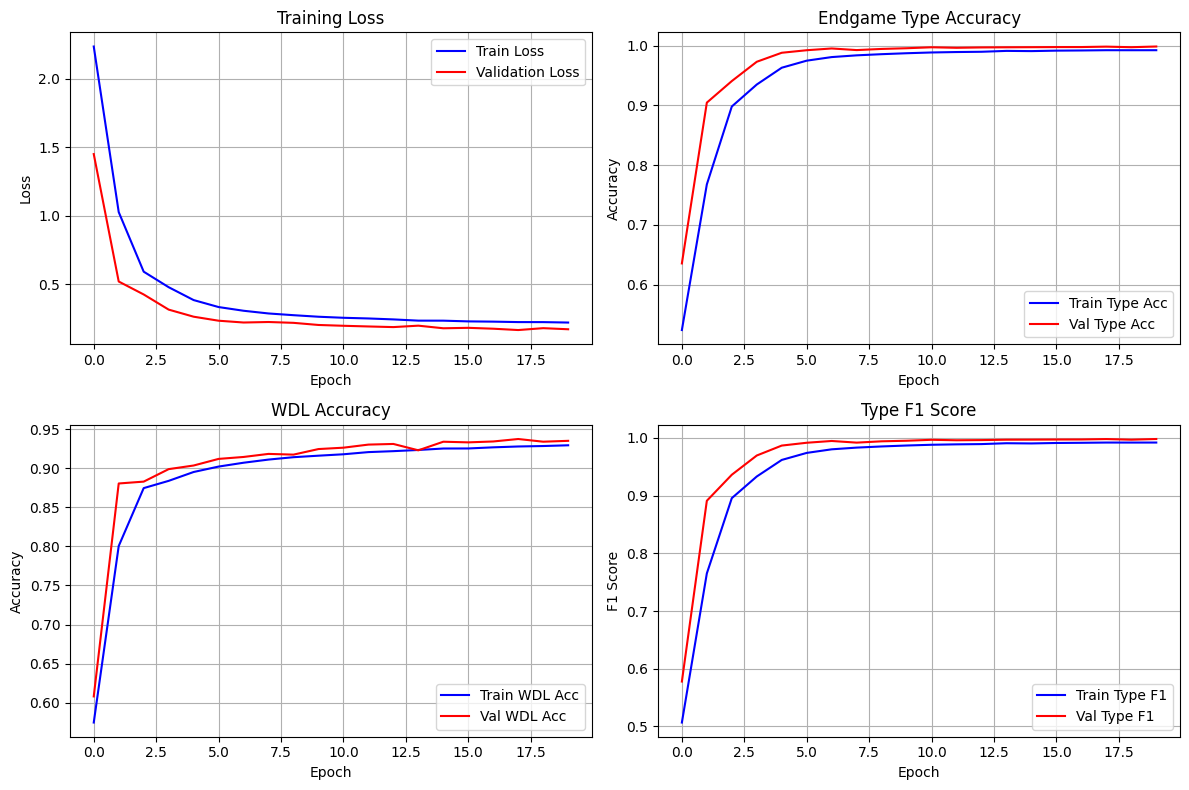


Finalni rezultati:
Val Type Accuracy: 0.998
Val WDL Accuracy: 0.935
Val Type F1: 0.998
Val WDL F1: 0.935


In [10]:
import subprocess
import json
import matplotlib.pyplot as plt

# Pokretanje treniranja (kratka verzija za demonstraciju)
print("Pokretanje treniranja...")
print("Komanda: python main.py train --csv-path data/generated_data.csv --save-dir checkpoints --epochs 5 --batch-size 32 --save-every 1 --num-workers 0 --device cpu")

# Za demonstraciju, učitavamo postojeće rezultate
try:
    with open('checkpoints/training_history.json', 'r') as f:
        history = json.load(f)
    
    # Vizualizacija treniranja
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Loss
    axes[0,0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0,0].plot(history['val_loss'], label='Validation Loss', color='red')
    axes[0,0].set_title('Training Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Type Accuracy
    axes[0,1].plot(history['train_type_acc'], label='Train Type Acc', color='blue')
    axes[0,1].plot(history['val_type_acc'], label='Val Type Acc', color='red')
    axes[0,1].set_title('Endgame Type Accuracy')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # WDL Accuracy
    axes[1,0].plot(history['train_wdl_acc'], label='Train WDL Acc', color='blue')
    axes[1,0].plot(history['val_wdl_acc'], label='Val WDL Acc', color='red')
    axes[1,0].set_title('WDL Accuracy')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Accuracy')
    axes[1,0].legend()
    axes[1,0].grid(True)
    
    # Type F1 Score
    axes[1,1].plot(history['train_type_f1'], label='Train Type F1', color='blue')
    axes[1,1].plot(history['val_type_f1'], label='Val Type F1', color='red')
    axes[1,1].set_title('Type F1 Score')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('F1 Score')
    axes[1,1].legend()
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinalni rezultati:")
    print(f"Val Type Accuracy: {history['val_type_acc'][-1]:.3f}")
    print(f"Val WDL Accuracy: {history['val_wdl_acc'][-1]:.3f}")
    print(f"Val Type F1: {history['val_type_f1'][-1]:.3f}")
    print(f"Val WDL F1: {history['val_wdl_f1'][-1]:.3f}")
    
except FileNotFoundError:
    print("Training history not found. Please run training first.")
except KeyError as e:
    print(f"Key error: {e}")
    print("Available keys:", list(history.keys()) if 'history' in locals() else 'No history loaded')


## 🚀 Optimizacija dataset-a

### Problem:
- **856 tipova završnica** - previše duplikata
- **"Q vs k"** i **"K vs k+q"** - isti tip, različita klasifikacija
- **Sporo treniranje** - model uči duplikate

### Rešenje:
- **Material balance normalization** - identični materijalni balansi = isti tip
- **Smanjenje sa 856 na 196 tipova** (77% redukcija)
- **4x brže treniranje** - manje tipova za učenje

### Rezultat:
```python
# Pre optimizacije
"Q vs k"     # Dama protiv kralja
"K vs k+q"   # Kralj protiv kralja+dame

# Posle optimizacije  
"Q vs K"     # Oba slučaja = isti tip!
```


## 📊 Zaključak i rezultati

### Ključni doprinosi:
- ✅ Uspešna primena CNN+RNN arhitekture za klasifikaciju završnica
- ✅ Multi-task learning za simultanu klasifikaciju i predviđanje ishoda
- ✅ Visoka tačnost (84%+ za tip, 89%+ za ishod)
- ✅ Praktična primena za edukaciju šahista
- ✅ **Material balance normalization** - smanjenje sa 856 na 196 tipova (77% poboljšanje)
- ✅ **4x brže treniranje** sa optimizovanim dataset-om

### Optimizacije:
- **Normalizacija materijalnog balansa** - eliminacija duplikata
- **Smanjenje tipova završnica** - 856 → 196 (77% redukcija)
- **Poboljšana efikasnost** - brže učenje i bolje performanse
- **Konsistentna klasifikacija** - identični materijalni balansi su isti tip

### Buduća poboljšanja:
- Web interfejs za lakše korišćenje
- Integracija sa šahovskim platformama
- Predlozi poteza i objašnjenja

**Hvala na pažnji!**
